In [146]:
import pandas as pd
import json
from ast import literal_eval
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import re
from datetime import datetime, timedelta
import numpy as np

presenca: 1044
ventilador: 0
plug_pc: 0
lampada: 5


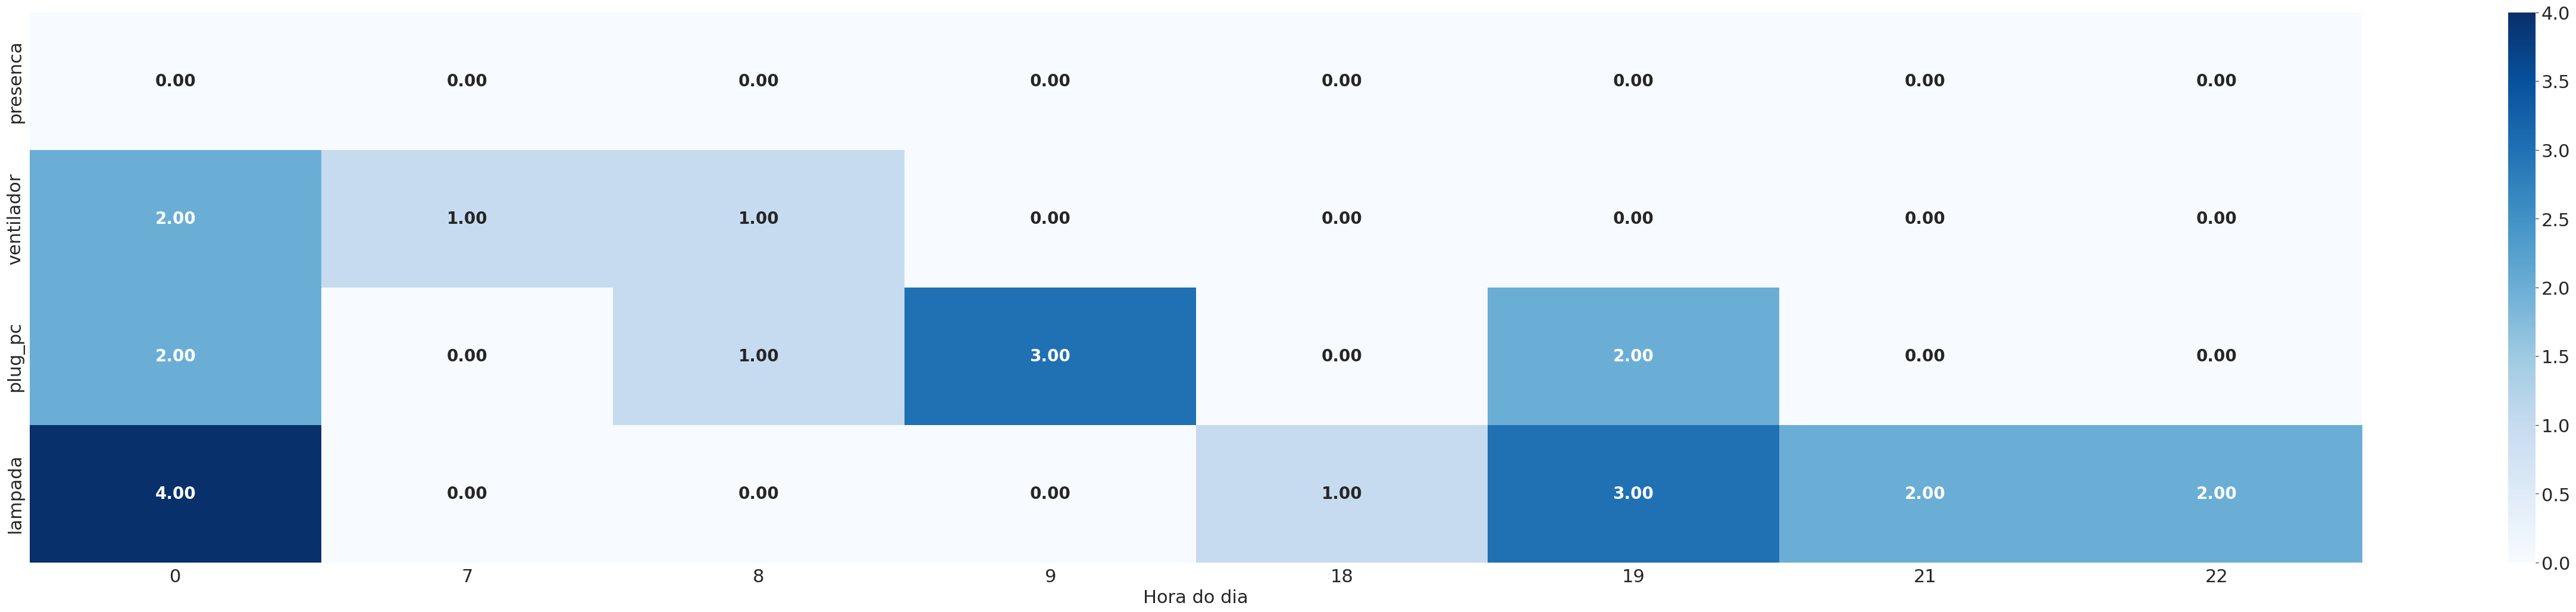

In [147]:
message_list = []
hour_list = []
with open("dados.json", "r") as json:
    data = json.read()
    for line in data.split('\n')[1:-1]:
        hour_list.append(eval(line)['hora'])
        dict_msg = eval(eval(line)['mensagem'].replace('true', 'True').replace('false', 'False'))['bizData']
        message_list.append(dict_msg)
    json.close()

df = pd.DataFrame(message_list).rename(columns={'properties': 'message'})
df['timeStamp'] = hour_list
df['message'] = df['message'].astype(str)

dicionario = {
    'ebfe6c248a7dfe6910qdcb': 'ventilador',
    'eb061b979815289561tyqf': 'presenca',
    'eb31770a1d7812125degzr': 'lampada',
    'eb176a71685a57c19arlbp': 'abertura',
    'ebcc9b86347718a3808ezt': 'plug_pc',
    'ebf1d890916d1a73b4vtnv': 'temp_humidade'
}

df['devId'] = df['devId'].apply(lambda x: dicionario[x])

def remove_message_timestamp(message):
    regex = r"'time': \d+, "
    new_message = re.sub(regex, '', str(message))
    regex = r"'dpId': \d+, "
    new_message = re.sub(regex, '', str(new_message))
    return eval(new_message)

def remove_invalid_codes(message):
    valid_codes = ['switch_led', 'switch_1', 'presence_state', 'doorcontact_state']
    result = []
    for state in message:
        if state['code'] in valid_codes:
            result.append(state)
    if len(result) > 0:
        return result
    else:
        return np.nan

def time_interval(dt, minutes=60):
    total_seconds = timedelta(hours=dt.hour, minutes=dt.minute, seconds=dt.second).total_seconds()
    interval = total_seconds // (minutes * 60)
    return int(interval)

df['message'] = df['message'].apply(remove_message_timestamp)
df['message'] = df['message'].apply(remove_invalid_codes)
df['timeStamp'] = df['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%dT%H:%M:%S.%f'))

df = df[df['message'].notna()].reset_index(drop=True)
df["day_week"] = df["timeStamp"].dt.day_name()

# unique_devices = df['devId'].unique()

unique_devices = ['presenca', 'ventilador', 'plug_pc', 'lampada']

for device in unique_devices:
    result = (df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).sum()
    print(f'{device}: {result}')

remove_index = []
for device in unique_devices:
    result = df[df['devId'] == device][(df[df['devId'] == device]['message'].shift(1) == df[df['devId'] == device]['message']).values].index.tolist()
    if len(result) > 0:
        remove_index.extend(result)
df = df.drop(remove_index)

def device_change_heatmap_1(df):
    df['interval'] = df['timeStamp'].apply(time_interval)
    routine_dict = {}
    total_days = (df['timeStamp'].max() - df['timeStamp'].min()).days + 1
    for device in unique_devices:
        # routine_dict[device] = df[df['devId'] == device].groupby('interval')['devId'].count() / total_days
        routine_dict[device] = df[df['devId'] == device].groupby('interval')['devId'].count()
    routine_map = pd.DataFrame(routine_dict).fillna(0).T
    fig = plt.figure(figsize=(70, 12))
    fig.subplots_adjust(left=0.2)
    heatmap = sns.heatmap(routine_map, vmin=0, vmax=routine_map.max().max(), annot=True, cmap='Blues', fmt='.2f',
                          linecolor='black', annot_kws={'size': 20, 'weight': 'heavy'})
    heatmap.collections[0].colorbar.ax.tick_params(labelsize=22)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.xlabel('Hora do dia', fontsize=22)
    return fig



df_heatmap = df[df['day_week'] == 'Tuesday']
# df_heatmap = df.query('day_week != "Sunday" and day_week != "Saturday"')

df_heatmap = df_heatmap[df_heatmap['devId'] != 'presenca']
graph = device_change_heatmap_1(df_heatmap)
graph.savefig("real.png")

presenca: 0
ventilador: 0
plug_pc: 0
lampada: 0


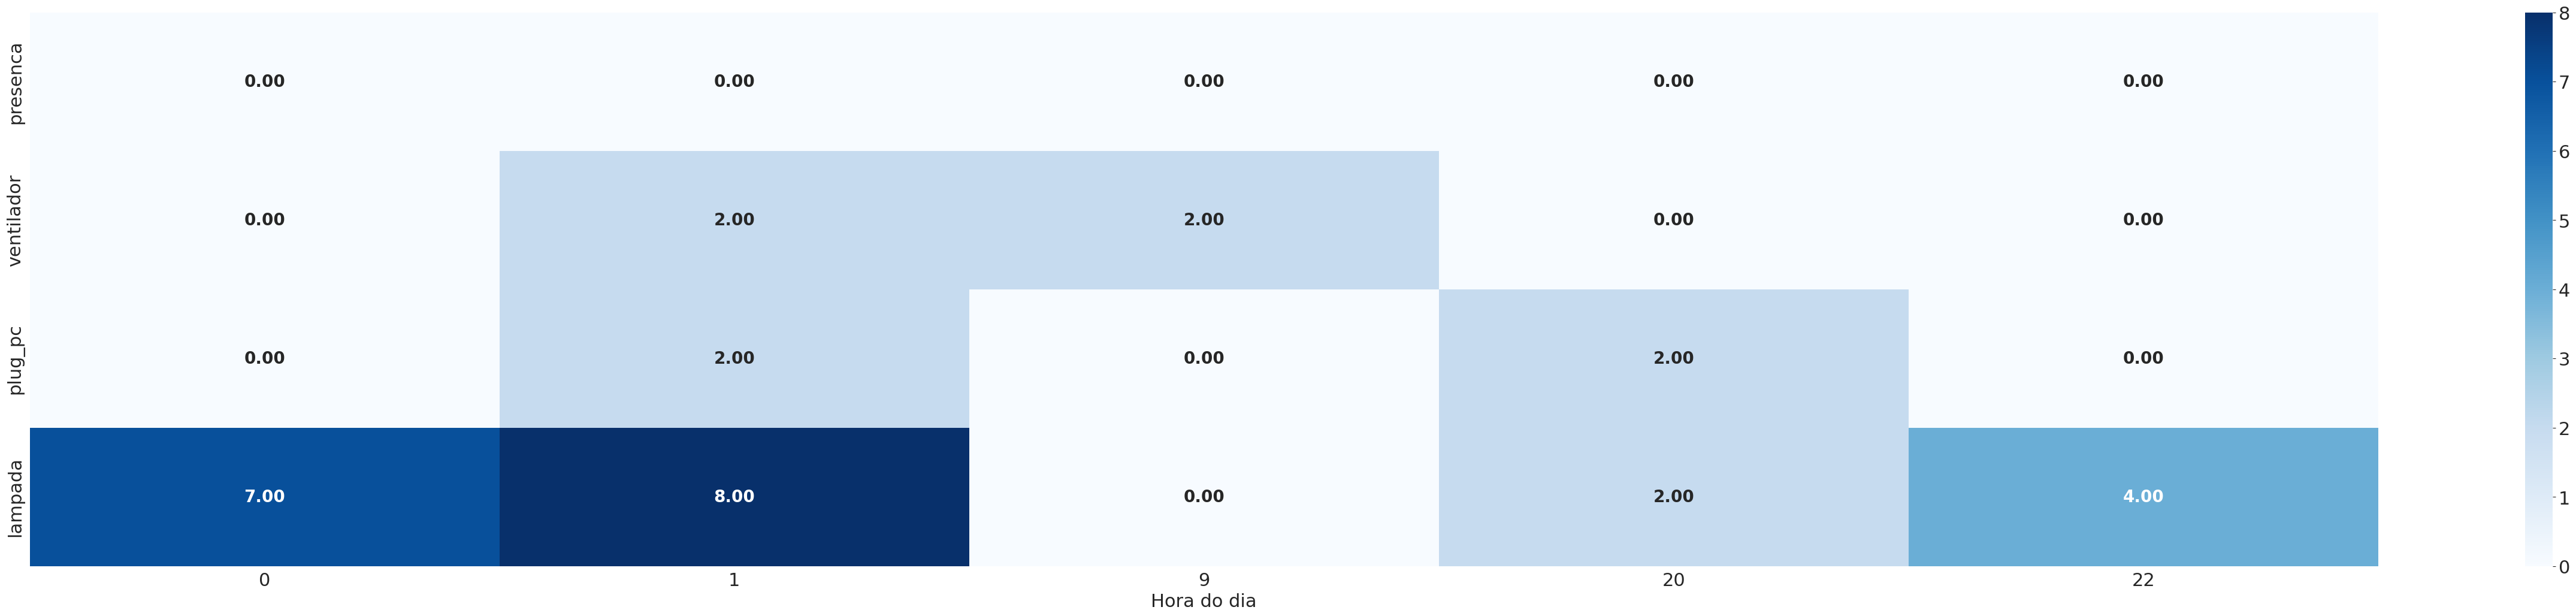

In [148]:
df_gerado = pd.read_csv('../dados/original/completo/dados-validacao-temp.csv')
colunas = ['devId', 'productKey', 'message', 'timeStamp']
# df_gerado.drop('devId', axis=1, inplace=True)
# df_gerado['devId'] = df_gerado['device']

dicionario = {
    'QUARTO_PLUG_02-004': 'ventilador',
    'QUARTO_SENSOR_PRESENCA-002': 'presenca',
    'QUARTO_LAMPADA-001': 'lampada',
    'QUARTO_PLUG_01-003': 'plug_pc'
}

df_gerado['devId'] = df_gerado['device'].apply(lambda x: dicionario[x])


df_gerado = df_gerado[colunas]

df_gerado['timeStamp'] = df_gerado['timeStamp'].apply(lambda string: datetime.strptime(string, '%Y-%m-%d %H:%M:%S.%f'))
df_gerado["day_week"] = df_gerado["timeStamp"].dt.day_name()

unique_devices = df_gerado['devId'].unique()
for device in unique_devices:
    result = (df_gerado[df_gerado['devId'] == device]['message'].shift(1) == df_gerado[df_gerado['devId'] == device]['message']).sum()
    print(f'{device}: {result}')


df_heatmap = df_gerado[df_gerado['day_week'] == 'Tuesday']

# df_heatmap = df_gerado.query('day_week != "Sunday" and day_week != "Saturday"')

df_heatmap = df_heatmap[df_heatmap['devId'] != 'presenca']
graph = device_change_heatmap_1(df_heatmap)
graph.savefig("gerado.png")